# 12 — LLM research assistant: asking the data questions in plain English

The earlier notebooks produce numbers: a curated dataset, fingerprints, and a tuned SVR that predicts CB2 pKi. A researcher who wants to *use* them still has to write pandas and RDKit code. This notebook adds a **large language model (LLM)** that can be asked questions in plain English ("which scaffolds are most potent?", "how much should I trust this prediction?") and answers them from the project's data.

**How it works: the LLM is not the model, it is the interface.** The LLM (DeepSeek, a general-purpose model trained on huge amounts of text, including chemistry) is *not* retrained on this data and is *not* attached to the SVR. It is given a list of **tools**: ordinary Python functions in `scripts/research_assistant.py`, each with a short description. When it needs a fact it replies with a request such as "call `find_similar` with this SMILES"; our code runs the function and sends the result back; the LLM then writes its answer. This pattern is called **tool use** (or function calling).

```
researcher ──question──▶ LLM ──"call query_table(...)"──▶ our Python (pandas / RDKit / SVR)
                         ▲                                         │
                         └──────────── result as JSON ◀────────────┘
                         │
                         └──answer (measured / predicted / general knowledge)──▶ researcher
```

**Why tools instead of pasting the data into the prompt?** LLMs read SMILES strings and long tables unreliably: they miscount atoms, misread rows and do arithmetic sloppily, while sounding confident. With tools, every number about the data comes from pandas, RDKit or the saved SVR, and the LLM's own knowledge is used only for explanation, clearly labelled.

**A pattern worth noticing.** Several tools here exist because a real answer was reviewed and found wrong. The assistant named a tetrahydropyran a "morpholine" from its SMILES; it described a mixed bucket of molecules as a chemotype after looking at one example; it measured "4-atom linkers" that were not linkers at all. None of these was fixed by asking the model to try harder. Each was fixed by computing the answer in Python and leaving the model only the parts it is good at: planning, combining results and explaining. That division is the real subject of this notebook.

**Scientific safeguards built into the tools:**
- **The reserved test sets stay unevaluated.** `predict_pki` refuses to predict a molecule in the prediction model's test set, because placing that prediction next to the measured value would be a test evaluation.
- **Every number comes with its uncertainty.** Group means carry 95% confidence intervals, differences carry bootstrap intervals, correlations carry Fisher-z intervals, measured pKi values carry a range based on the ~0.54 pKi measurement noise (notebook 10), and every prediction carries a 95% **prediction interval** taken from the SVR's real validation errors. The LLM is told to copy these intervals, never to estimate its own.
- **Scaffold and ring names come from RDKit, not the LLM.** Ring systems are matched against a library of named ring patterns; anything unmatched is described factually rather than guessed.
- **Groups are described by their composition.** `group_composition` reports the top series and papers with shares, so a set of molecules is never characterised from one example.
- **Linkers are counted, not pattern-matched.** `find_linkers` counts a chain only when its atoms lie outside every ring, separating real linker SAR from paths that merely run through a fused ring system.
- **Series are tagged with how many papers they come from.** A "series" from one paper mostly reflects one lab's optimisation and assay, which the LLM is told to say.
- **The whole project is readable, except the API key.** The LLM can search and read every text file: READMEs, notebooks (explanations, code and printed results), scripts, tests, requirements, run manifests (settings, hyperparameters, software versions) and result tables, so it can answer *how* and *why* questions, not just *what*. Three independent safeguards keep the key away from it: `.env` and other secret-looking files are never added to the library (and only library names can be opened); any file whose contents include the key is skipped wherever it is; and the key, or anything shaped like an API key, is replaced by `[redacted]` in every tool result.
- The live SVR predictions are checked against the saved validation predictions below, so the tool is the same model notebook 07 evaluated.

**Running it:** install the extra packages once, on top of the pinned environment:

```
uv pip install --python .venv/bin/python -r requirements-llm.txt
```

Create a file named `.env` in the project root containing `DEEPSEEK_API_KEY=your-key` (git ignores `.env`, so the key is never committed). Without a key, the tool demonstrations still run and the LLM cells are skipped. The chat interface is a separate Streamlit app:

```
.venv/bin/streamlit run scripts/assistant_app.py
```

**Cost and speed:** DeepSeek charges per token (a token is roughly ¾ of a word). A typical question costs well under one US cent and takes a few seconds; the evaluation at the end costs about ten cents. Questions, tool results and answers are sent to DeepSeek's servers, which is fine for this public ChEMBL data but would matter for unpublished compounds.

In [1]:
from pathlib import Path
import sys
# Find the project folder whether the notebook runs from notebooks/ or the project root.
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "scripts"))
import json
import re
import time

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from rdkit import Chem
from rdkit.Chem import Descriptors

import research_assistant as assistant

# Load everything the tools need once: curated molecules, every measurement, source papers,
# fingerprints recomputed with notebook 03's settings (checked against the saved matrix), and
# the tuned SVR from notebook 07. Loading takes a few seconds, mostly computing descriptors.
data = assistant.ResearchData(project_root)

print(f"{'Item':<40} | {'Count':>8}")
print(f"{'Curated molecules (compounds table)':<40} | {len(data.compounds):>8,}")
print(f"{'Measurements, including removed':<40} | {len(data.measurements):>8,}")
print(f"{'Source documents with retained Ki data':<40} | {(data.documents['n_measurements'] > 0).sum():>8,}")
print(f"{'Molecules with a ChEMBL name':<40} | {data.compounds['name'].notna().sum():>8,}")
print(f"{'SVR training molecules (' + assistant.PREDICTION_SPLIT + ' split)':<40} | {len(data.training_rows):>8,}")
print(f"{'Tools available to the LLM':<40} | {len(assistant.TOOL_SCHEMAS):>8,}")

Item                                     |    Count
Curated molecules (compounds table)      |    3,576
Measurements, including removed          |    4,081
Source documents with retained Ki data   |      274
Molecules with a ChEMBL name             |       30
SVR training molecules (scaffold split)  |    2,778
Tools available to the LLM               |       21


## What the LLM is given

The LLM sees only two things about this project: a **system prompt** (standing instructions, printed further down) and these **tool descriptions**. Each description is written for the LLM, so it explains when to use the tool. The inputs are described in JSON Schema, a standard format for saying "this argument is a string, this one a list of numbers".

In [2]:
# Print each tool's name and the first sentence of the description the LLM reads.
print(f"{'Tool':<22} | {'Inputs':<58} | What the LLM is told")
print("-" * 150)
for schema in assistant.TOOL_SCHEMAS:
    function = schema["function"]
    inputs = ", ".join(function["parameters"]["properties"]) or "(none)"
    first_sentence = function["description"].split(". ")[0].rstrip(".") + "."
    print(f"{function['name']:<22} | {inputs[:58]:<58} | {first_sentence[:68]}")

Tool                   | Inputs                                                     | What the LLM is told
------------------------------------------------------------------------------------------------------------------------------------------------------
dataset_overview       | (none)                                                     | Start here.
query_table            | table, filters, substructure, exclude_substructure, column | List rows of a table matching filters, optionally containing / not c
aggregate_table        | group_by, table, value_column, filters, substructure, excl | Group rows and summarise a numeric column per group: count, mean wit
compare_substructure   | pattern, value_column, filters                             | SAR check: compare a value (default pKi) between compounds with and 
correlation            | x, y, table, filters, substructure                         | Pearson and Spearman correlation between two numeric columns (e.g.
describe_molecule      | s

## The tools on their own (no LLM yet)

Each tool is a normal Python function, so it can be called directly. `run_tool` is the exact path the LLM's requests take: it receives the tool name and arguments, runs the function, and returns the JSON text the LLM will read (plus any images, which go only to the person). Calling it here shows precisely what the LLM sees.

**1. Filtering and sorting.** The strongest binders: pKi ≥ 10 means Ki ≤ 0.1 nM.

In [3]:
# Ask the same way the LLM would: a table, filter conditions, columns, sorting and a row limit.
text, images = assistant.run_tool(data, "query_table", {
    "filters": [{"column": "pki", "op": ">=", "value": 10}],
    "columns": ["chembl_ids", "pki", "mol_weight", "logp", "scaffold_size"],
    "sort_by": "pki", "limit": 8})
result = json.loads(text)   # The LLM receives this text; here it is turned back into Python to print.
print(f"Molecules with pKi >= 10: {result['total_matching']} (showing {result['returned']})\n")
print(f"{'ChEMBL ID':<16} | {'pKi':>6} | {'MW':>7} | {'cLogP':>6} | {'Series size':>11}")
for row in result["rows"]:
    print(f"{row['chembl_ids'][:16]:<16} | {row['pki']:>6.2f} | {row['mol_weight']:>7.1f} | {row['logp']:>6.2f} | {row['scaffold_size']:>11,}")

Molecules with pKi >= 10: 13 (showing 8)

ChEMBL ID        |    pKi |      MW |  cLogP | Series size
CHEMBL600647     |  10.72 |   426.5 |   4.22 |          12
CHEMBL3410832    |  10.68 |   440.5 |   4.23 |          12
CHEMBL3410813    |  10.59 |   482.6 |   5.78 |          12
CHEMBL3233404    |  10.49 |   388.5 |   6.68 |          56
CHEMBL216276     |  10.41 |   441.4 |   5.19 |           1
CHEMBL3410818    |  10.28 |   396.4 |   2.59 |           2
CHEMBL5266788    |  10.11 |   421.6 |   4.72 |           2
CHEMBL3410729    |  10.06 |   439.5 |   4.03 |           1


**2. A structure–activity question.** Do molecules containing a morpholine ring bind more strongly? The tool compares pKi with and without the group and runs a Mann–Whitney test (a rank-based test that does not assume normal distributions). Its `caution` field matters: across a whole dataset, a group can look "good" only because it happens to appear in a potent chemical series. That is *confounding*, and the system prompt tells the LLM to point it out.

In [4]:
result = json.loads(assistant.run_tool(data, "compare_substructure", {"pattern": "morpholine"})[0])
print(f"{'Group':<18} | {'n':>6} | {'Median pKi':>10} | {'Mean pKi':>8} | {'95% CI of mean':>15}")
for label, key in [("With morpholine", "with_pattern"), ("Without", "without_pattern")]:
    group = result[key]
    low, high = group["mean_ci95"]
    print(f"{label:<18} | {group['n']:>6,} | {group['median']:>10.2f} | {group['mean']:>8.2f} | {low:>6.2f} - {high:<6.2f}")
# The bootstrap redraws both groups 2,000 times; the middle 95% of the resampled differences is the interval.
low, high = result["median_difference_ci95"]
print(f"\nMedian difference {result['median_difference']:+.2f} pKi (95% bootstrap CI {low:+.2f} to {high:+.2f}), "
      f"Mann-Whitney p = {result['mann_whitney_p_value']:.2g}")
print("Caution passed to the LLM:", result["caution"])

Group              |      n | Median pKi | Mean pKi |  95% CI of mean
With morpholine    |    211 |       7.43 |     7.42 |   7.29 - 7.55  
Without            |  3,365 |       7.03 |     7.08 |   7.04 - 7.12  

Median difference +0.40 pKi (95% bootstrap CI +0.16 to +0.58), Mann-Whitney p = 1e-05
Caution passed to the LLM: A difference across the whole dataset mixes many chemical series; compare matched pairs or one scaffold before concluding the group itself causes it.


**3. Chemical series, named by RDKit.** Grouping by Bemis–Murcko scaffold gives one row per chemical series. Each row now carries an RDKit-derived `scaffold_name`, the 95% confidence interval of its mean pKi, and `n_papers`. Read the intervals before ranking series: two series whose intervals overlap are not clearly different. And a series from one paper is mostly one lab's optimised compounds measured in one assay.

How the naming works: RDKit splits the scaffold into ring systems (fused rings count as one), then checks each against a library of named ring patterns (`RING_SYSTEMS` in `research_assistant.py`). A name is used only when a pattern covers exactly that ring system's atoms; otherwise the system is described factually (ring sizes, aromaticity, heteroatoms) instead of guessed.

In [5]:
result = json.loads(assistant.run_tool(data, "aggregate_table", {"group_by": "scaffold", "limit": 10})[0])
print(f"{'Series (RDKit name)':<62} | {'n':>3} | {'Mean pKi':>8} | {'95% CI':>13} | {'Papers':>6}")
for group in result["groups"]:
    interval = f"{group['mean_ci95_low']:.2f} - {group['mean_ci95_high']:.2f}"
    print(f"{group['scaffold_name'][:62]:<62} | {group['count']:>3} | {group['mean']:>8.2f} | {interval:>13} | {group['n_papers']:>6}")

Series (RDKit name)                                            |   n | Mean pKi |        95% CI | Papers
benzene                                                        |  93 |     6.37 |   6.18 - 6.56 |     15
naphthalene + indole                                           |  81 |     7.83 |   7.66 - 8.00 |      8
benzo[c]chromene (dibenzopyran, the THC-type tricyclic core)   |  56 |     8.23 |   7.96 - 8.49 |     16
benzene + benzene                                              |  50 |     6.79 |   6.48 - 7.10 |      7
coumarin (2H-chromen-2-one) + benzene                          |  48 |     5.86 |   5.70 - 6.03 |      4
adamantane + 4-quinolone (quinolin-4(1H)-one)                  |  36 |     7.89 |   7.60 - 8.19 |     10
indole + tetrahydropyran (oxane) + cyclopropane                |  31 |     8.26 |   7.93 - 8.59 |      3
benzene + cyclohexane                                          |  31 |     6.44 |   6.20 - 6.67 |      5
acyclic (no rings; a catch-all bucket, not a chemical s

**4. Looking up a known drug.** Nabilone is an approved synthetic cannabinoid. The lookup returns the curated value, every individual measurement with its assay, and the source papers. A molecule whose measurements were all removed during curation (for example cannabidiol, whose repeat measurements disagreed by ≥ 1 pKi) is reported as removed, with the reason, instead of "not found".

In [6]:
result = json.loads(assistant.run_tool(data, "lookup_compound", {"identifier": "nabilone"})[0])
compound = result["compound"]
low, high = compound["measured_pki_approx_95_range"]
print(f"{compound['name']} ({compound['chembl_ids']}): curated pKi {compound['pki']:.2f} = Ki {compound['ki_nm']:.1f} nM, "
      f"from {compound['n_measurements']} measurement(s); approximate 95% range {low:.2f} - {high:.2f}\n")
print(f"{'Ki (nM)':>8} | {'pKi':>5} | {'Year':>4} | Assay")
for row in result["measurements"]:
    print(f"{row['ki_nm']:>8.2f} | {row['pki']:>5.2f} | {row['year']:>4} | {row['assay_description'][:90]}")

removed = json.loads(assistant.run_tool(data, "lookup_compound", {"identifier": "cannabidiol"})[0])
reasons = sorted({row["review_reason"] for row in removed["removed_measurements"]})
print(f"\nCannabidiol: in modeling dataset = {removed.get('in_modeling_dataset')}; "
      f"{len(removed['removed_measurements'])} measurement(s) removed, reason(s): {', '.join(reasons)}")

Nabilone (CHEMBL2218896): curated pKi 7.98 = Ki 10.5 nM, from 2 measurement(s); approximate 95% range 7.23 - 8.73

 Ki (nM) |   pKi | Year | Assay
   17.60 |  7.75 | 2010 | Displacement of [3H]CP-55940 from human recombinant CB2 receptor expressed in CHO cells
    6.31 |  8.20 | 2011 | Displacement of [3H]-CP55940 from human CB2 receptor expressed in CHO cells by liquid scin

Cannabidiol: in modeling dataset = False; 4 measurement(s) removed, reason(s): pki_range_ge_1.0


**5. A prediction for a new molecule, with its prediction interval.** This molecule is nabilone with its long dimethylheptyl side chain shortened to the pentyl chain of THC. It is not in the dataset. The tool returns the SVR's prediction together with how much to trust it.

The **prediction interval** is built by *split conformal prediction*, a simple, assumption-light method: take the scaffold-split validation molecules whose nearest training molecule was about as similar as this one's, look at how far the SVR's predictions were from their measured values, and find the error size that 95% of them stayed within. The same distance either side of the new prediction is its 95% interval. Because those validation values are themselves noisy lab measurements, the interval describes where a new *measurement* would be expected to fall.

In dataset: False
Predicted pKi 7.00 (Ki about 101 nM)
  95% prediction interval 5.48 - 8.51; 80% interval 6.08 - 7.91
  Split conformal from the 339 scaffold-split validation molecules whose nearest training molecule had Tanimoto 0.5-0.8, like this one: 95% of their measured pKi values fell within +/-1.52 of the prediction. The interval is for the value a new measurement would give, so it includes lab measurement noise.
  validation_mae_pki                             0.601
  validation_rmse_pki                            0.764
  validation_mae_in_this_similarity_band         0.571
  measurement_noise_floor_pki                    0.540
Nearest training molecule: Tanimoto 0.69, measured pKi 7.98
Trust: moderate: related chemistry was in the training data


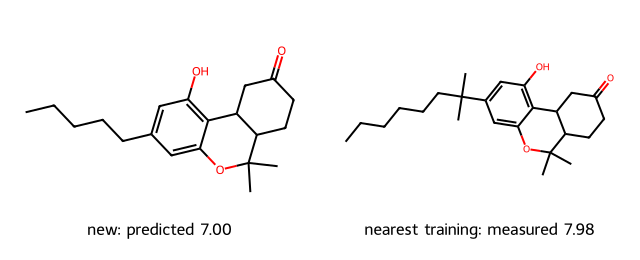

In [7]:
new_molecule = "CCCCCc1cc(O)c2c(c1)OC(C)(C)C1CCC(=O)CC21"   # Nabilone core with a pentyl chain.
print("In dataset:", json.loads(assistant.run_tool(data, "describe_molecule", {"smiles": new_molecule})[0])["in_dataset"])
result = json.loads(assistant.run_tool(data, "predict_pki", {"smiles": new_molecule})[0])
low, high = result["prediction_interval_95"]
inner_low, inner_high = result["prediction_interval_80"]
print(f"Predicted pKi {result['predicted_pki']:.2f} (Ki about {result['predicted_ki_nm']:.0f} nM)")
print(f"  95% prediction interval {low:.2f} - {high:.2f}; 80% interval {inner_low:.2f} - {inner_high:.2f}")
print(f"  {result['interval_method']}")
for key, value in result["typical_error"].items():
    print(f"  {key:<45} {value:>6.3f}")
nearest = result["nearest_training_molecule"]
print(f"Nearest training molecule: Tanimoto {nearest['tanimoto']:.2f}, measured pKi {nearest['measured_pki']:.2f}")
print("Trust:", result["trust"])

# Draw the new molecule next to its nearest training neighbour. Images go to the person, never to the LLM.
text, images = assistant.run_tool(data, "draw_molecules", {
    "smiles_list": [new_molecule, nearest["smiles"]],
    "legends": [f"new: predicted {result['predicted_pki']:.2f}", f"nearest training: measured {nearest['measured_pki']:.2f}"]})
display(Image(data=images[0]))

**6. The safeguards, checked.** Three checks before the LLM is allowed to use the prediction tool:

1. **Same model as notebook 07.** Live predictions for scaffold-split validation molecules must match the predictions saved when the SVR was evaluated.
2. **Test molecules are refused.** Every reserved test molecule of the scaffold split must come back with the prediction withheld.
3. **The intervals deliver their coverage.** In each similarity band, at least 95% of validation molecules must fall inside the 95% interval. Split conformal guarantees this on the molecules the width came from, so this checks the code, not the method; new molecules are expected to land close to 95% only if they resemble the validation molecules.

In [8]:
# Check 1: the tool reproduces the saved validation predictions (the tool rounds to 0.01 pKi).
saved = pd.read_csv(assistant.SVR_FOLDER / "predictions.csv")
saved = saved[(saved["split_strategy"] == assistant.PREDICTION_SPLIT) & (saved["subset"] == "validation")]
live = [json.loads(assistant.run_tool(data, "predict_pki", {"smiles": s})[0])["predicted_pki"] for s in saved["rdkit_smiles"]]
largest_gap = np.max(np.abs(np.array(live) - saved["predicted_pki"].to_numpy()))
assert largest_gap <= 0.006, "The tool's SVR does not reproduce notebook 07's saved predictions"
print(f"Check 1 passed: {len(saved)} validation predictions reproduced; largest difference {largest_gap:.4f} pKi (rounding).")

# Check 2: no reserved test molecule gets a prediction.
test_smiles = data.compounds.loc[data.compounds[f"{assistant.PREDICTION_SPLIT}_subset"] == "test", "smiles"]
withheld = sum(json.loads(assistant.run_tool(data, "predict_pki", {"smiles": s})[0]).get("prediction_withheld", False)
               for s in test_smiles)
assert withheld == len(test_smiles), "A reserved test molecule received a prediction"
print(f"Check 2 passed: all {withheld} reserved test molecules were refused.")

# Check 3: interval coverage per nearest-training-similarity band.
errors = data.validation_errors
print(f"\n{'Similarity band':<16} | {'Molecules':>9} | {'95% half-width':>14} | {'Covered':>7}")
for low, high in assistant.PREDICTION_BANDS:
    band = errors[(errors["maximum_tanimoto"] >= low) & (errors["maximum_tanimoto"] < high)]["absolute_error"]
    half_width = assistant.conformal_half_width(band, 0.95)
    covered = (band <= half_width).mean()
    assert covered >= 0.95, "Prediction interval covers fewer than 95% of validation molecules"
    print(f"{f'{low:.1f} - {min(high, 1):.1f}':<16} | {len(band):>9} | {half_width:>14.2f} | {covered:>7.1%}")
print("Check 3 passed.")

Check 1 passed: 461 validation predictions reproduced; largest difference 0.0050 pKi (rounding).
Check 2 passed: all 337 reserved test molecules were refused.

Similarity band  | Molecules | 95% half-width | Covered
0.0 - 0.5        |        36 |           1.93 |  100.0%
0.5 - 0.8        |       339 |           1.52 |   95.3%
0.8 - 1.0        |        86 |           1.66 |   96.5%
Check 3 passed.


**7. Activity cliffs.** Pairs of near-identical molecules (Tanimoto ≥ 0.8) whose measured pKi differs by at least 1 log unit, a factor of 10 in Ki. These are where a small structural change matters most, and where fingerprint models struggle. The search compares all ~6.4 million molecule pairs once and then reuses the result.

A 1 pKi gap between two single measurements is not automatically real: each measurement carries ~0.54 pKi of noise, so their difference has a noise SD of 0.54 × √2 ≈ 0.76 pKi. Each pair is therefore marked as beyond noise only when its approximate 95% range excludes zero.

566 pairs meet the definition: Tanimoto >= 0.8 and |pKi difference| >= 1.0; 243 of them exceed measurement noise

Tanimoto | Stronger pKi | Weaker pKi | Difference | Approx. 95% range | Beyond noise
    0.86 |         9.00 |       5.53 |       3.46 |       1.97 - 4.96 | yes         
    0.80 |         9.25 |       5.87 |       3.38 |       1.88 - 4.88 | yes         
    0.82 |         9.30 |       6.00 |       3.30 |       1.80 - 4.80 | yes         
    0.87 |         8.80 |       5.53 |       3.26 |       1.76 - 4.76 | yes         


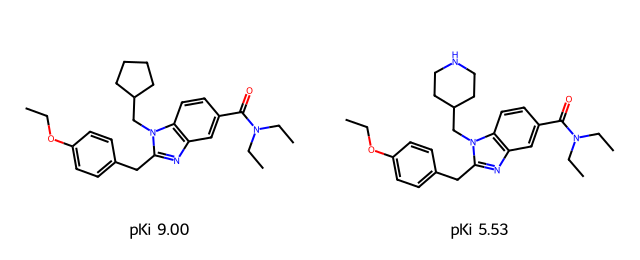

In [9]:
result = json.loads(assistant.run_tool(data, "find_activity_cliffs", {"limit": 4})[0])
print(f"{result['pairs_found']:,} pairs meet the definition: {result['definition']}; "
      f"{result['pairs_beyond_measurement_noise']:,} of them exceed measurement noise\n")
print(f"{'Tanimoto':>8} | {'Stronger pKi':>12} | {'Weaker pKi':>10} | {'Difference':>10} | {'Approx. 95% range':>17} | {'Beyond noise':<12}")
for pair in result["pairs"]:
    low, high = pair["difference_approx_95_range"]
    print(f"{pair['tanimoto']:>8.2f} | {pair['stronger_pki']:>12.2f} | {pair['weaker_pki']:>10.2f} | "
          f"{pair['pki_difference']:>10.2f} | {f'{low:.2f} - {high:.2f}':>17} | {'yes' if pair['beyond_measurement_noise'] else 'no':<12}")
top = result["pairs"][0]
text, images = assistant.run_tool(data, "draw_molecules", {
    "smiles_list": [top["stronger_smiles"], top["weaker_smiles"]],
    "legends": [f"pKi {top['stronger_pki']:.2f}", f"pKi {top['weaker_pki']:.2f}"]})
display(Image(data=images[0]))

**8. Questions about the project itself.** The data tools answer *what* questions about molecules. To answer *how* and *why* questions (why the SVR was chosen, how the splits were built, which settings were searched) the LLM gets four more tools:

- `compare_models` recomputes every model's validation RMSE from its saved predictions, with 95% bootstrap intervals and a **paired** comparison against the best model: each resample redraws the same validation molecules for every model, so the luck of the draw affects both sides equally. This is the method of notebook 10, extended to ChemBERTa.
- `search_project`, `list_project_documents` and `read_project_document` give read access to every text file in the project except secrets (see the safeguards at the top). Each document is split into sections (a notebook cell, a README heading, a block of table rows), so the LLM reads only what it needs. Search ranks sections TF-IDF style: rare words such as "Kramer" count for more than common ones such as "model".

In [10]:
result = json.loads(assistant.run_tool(data, "compare_models", {"include_dummies": False})[0])
print(f"{'Split':<9} | {'Model':<27} | {'Variant':<14} | {'RMSE':>6} | {'95% CI':>13} | {'Gap closed':>10} | Versus best")
for row in result["models"]:
    interval = f"{row['rmse_ci95_low']:.3f} - {row['rmse_ci95_high']:.3f}"
    print(f"{row['split_strategy']:<9} | {row['model']:<27} | {row['variant']:<14} | {row['rmse_pki']:>6.3f} | "
          f"{interval:>13} | {row['share_of_gap_to_noise_floor_closed']:>10.0%} | {row['versus_best']}")

Split     | Model                       | Variant        |   RMSE |        95% CI | Gap closed | Versus best
random    | Support vector regression   | tuned          |  0.685 | 0.631 - 0.740 |        78% | best model on this split
random    | Random forest               | baseline       |  0.721 | 0.667 - 0.775 |        72% | worse than the best (interval above 0)
random    | Support vector regression   | baseline       |  0.724 | 0.666 - 0.780 |        72% | worse than the best (interval above 0)
random    | Random forest               | tuned          |  0.724 | 0.667 - 0.783 |        72% | worse than the best (interval above 0)
random    | Fine-tuned ChemBERTa        | fixed settings |  0.770 | 0.716 - 0.825 |        65% | worse than the best (interval above 0)
random    | XGBoost                     | tuned          |  0.774 | 0.714 - 0.829 |        64% | worse than the best (interval above 0)
random    | Multilayer perceptron       | tuned          |  0.802 | 0.725 - 0.875 |      

In [11]:
# What the library contains, by kind of file.
listing = json.loads(assistant.run_tool(data, "list_project_documents", {})[0])
kinds = pd.Series([Path(f).suffix for files in listing["documents_by_folder"].values() for f in files]).value_counts()
print(f"{listing['total']} readable documents: " + ", ".join(f"{count} {kind}" for kind, count in kinds.items()))

# The safeguard: names outside the allowlist are refused, however they are written.
for name in [".env", "../.env", "provenance/raw/chembl_cb2_20260922T165756862384Z/chembl_cb2_activity.json"]:
    print(f"  read {name!r:<78} -> {json.loads(assistant.run_tool(data, 'read_project_document', {'name': name})[0])['error'][:40]}")

# A search, then reading the best hit, exactly as the LLM would.
hits = json.loads(assistant.run_tool(data, "search_project", {"text": "Kramer noise floor", "limit": 3})[0])["hits"]
print(f"\n{'Score':>5} | {'Document':<40} | {'Section':>7} | Title")
for hit in hits:
    print(f"{hit['score']:>5.1f} | {hit['name']:<40} | {hit['section']:>7} | {hit['title'][:60]}")
top = json.loads(assistant.run_tool(data, "read_project_document", {"name": hits[0]["name"], "sections": [hits[0]["section"]]})[0])
print("\nFirst 600 characters of the top hit:\n" + top["sections"][0]["text"][:600])

157 readable documents: 64 .csv, 32 .json, 28 .py, 13 .ipynb, 12 .md, 4 .txt, 3 , 1 .MD
  read '.env'                                                                         -> ValueError: '.env' is not in the project
  read '../.env'                                                                      -> ValueError: '../.env' is not in the proj
  read 'provenance/raw/chembl_cb2_20260922T165756862384Z/chembl_cb2_activity.json'    -> ValueError: 'provenance/raw/chembl_cb2_2

Score | Document                                 | Section | Title
 23.2 | notebooks/12_llm_research_assistant.ipynb |      20 | cell 20 (code): # What the library contains, by kind of file
 22.0 | notebooks/10_noise_ceiling.ipynb         |       0 | cell 0 (text): 10 — Noise ceiling: how close do the models g
 21.2 | notebooks/10_noise_ceiling.ipynb         |       1 | cell 1 (code): project_root = Path.cwd().resolve()

First 600 characters of the top hit:
CODE:
# What the library contains, by kind of file.
listing

**9. Two tools that exist because the assistant got something wrong.** Both were added after reviewing real answers, and both move a judgement out of the language model and into code.

*Linker length.* Asked how affinity varies with the length of the chain joining an aromatic core to a terminal group, the assistant wrote its own SMARTS, such as `[a]-[CX4]-[CX4]-[CX4]-[CX4]-c1ccccc1`, and reported a mean pKi per chain length. That pattern matches four sp3 carbons between an aromatic atom and a phenyl, but those carbons may lie **inside a fused ring system** rather than forming a flexible chain, and nothing in the match says which. `find_linkers` separates them: a chain counts only when every one of its atoms is outside all rings. The table below shows why this matters — the apparent "4-atom linker" group contains no actual linkers at all.

*What a group is.* Asked to describe a bucket of molecules, the assistant looked at the one example it had drawn and labelled the whole bucket a chemotype it was not. `group_composition` answers "what is this set made of?" with counts and shares, so the description comes from the data rather than from whichever molecule happened to be drawn first.

In [12]:
result = json.loads(assistant.run_tool(data, "find_linkers", {"terminal_group": "benzene", "max_linker_atoms": 4})[0])
print("Chain of sp3 carbons between any aromatic atom and a phenyl group:\n")
print(f"{'Chain atoms':>11} | {'Real chains':>11} | {'Ring paths only':>15} | {'Papers':>6} | {'Mean pKi':>8} | {'95% CI':>13}")
for row in result["lengths"]:
    interval = (f"{row['mean_ci95'][0]:.2f} - {row['mean_ci95'][1]:.2f}" if row["mean_ci95"] else "-")
    mean = f"{row['mean_pki']:.2f}" if row["mean_pki"] is not None else "-"
    print(f"{row['linker_atoms']:>11} | {row['n_genuine_linker']:>11} | {row['n_ring_path_only']:>15} | "
          f"{row['n_papers']:>6} | {mean:>8} | {interval:>13}")
print("\n" + result["how_to_read"])

# What the mono-branched benzyl bucket actually consists of, rather than what its first example looks like.
composition = json.loads(assistant.run_tool(data, "group_composition", {"substructure": "[a]-[CX4H1]-c1ccccc1"})[0])
print(f"\nMolecules with a single-hydrogen carbon between an aromatic ring and a phenyl: "
      f"{composition['n_molecules']} molecules from {composition['n_papers']} papers\n")
print(f"{'Series (RDKit name)':<62} | {'n':>3} | {'Share':>6} | {'Mean pKi':>8}")
for group in composition["top_groups"][:4]:
    print(f"{group['scaffold_name'][:62]:<62} | {group['n']:>3} | {group['share']:>6.0%} | {group['mean_pki']:>8.2f}")
print("\n" + composition["how_to_read"])

Chain of sp3 carbons between any aromatic atom and a phenyl group:

Chain atoms | Real chains | Ring paths only | Papers | Mean pKi |        95% CI
          0 |         899 |               0 |    109 |     6.73 |   6.67 - 6.80
          1 |         437 |              33 |     59 |     6.91 |   6.80 - 7.02
          2 |           5 |               4 |      5 |     6.96 |   5.80 - 8.11
          3 |           1 |              16 |      1 |     6.80 |             -
          4 |           0 |              10 |      0 |        - |             -

linker_atoms is the number of sp3 carbons between the core and the terminal group; 0 means directly attached. n_genuine_linker counts molecules where those carbons are outside every ring (a real flexible chain) and is what the statistics describe. n_ring_path_only counts molecules matched only through atoms inside a fused ring system: those are NOT linkers of that length and are excluded. A length with few genuine molecules, or n_papers of 1-2, ca

## Talking to the LLM

Now the LLM drives. The **system prompt** below is the standing instruction it receives at the start of every conversation. Then one question is asked, and every tool call the LLM makes is printed as it happens, so you can see the plan it chose before reading its answer.

The conversation is a list of messages: the system prompt, the user's question, the assistant's tool requests, our tool results, and finally the answer. `chat_turn` in `research_assistant.py` runs that loop: it sends the list to DeepSeek, runs any tools requested, appends the results, and repeats until the LLM answers without asking for more tools (at most 15 rounds).

Notice how long the system prompt is: it ends with every table, column, named substructure and named ring system. That is deliberate. Each round trip costs a few seconds, so a question that spends its first round calling a tool just to read the column names is a round wasted. Because the prompt is fixed text it sits in DeepSeek's cache, where repeated tokens cost about a thirtieth of new ones. Measured on the evaluation below, moving the schema into the prompt and trimming oversized tool results cut the average question from 14.5 to 5.9 seconds.

DeepSeek runs in **thinking mode**: it reasons privately before each reply. It is kept on because the measurement says it is nearly free here (about one extra second per question) and it *reduces* the number of tool calls, because the model plans before acting. With tools, DeepSeek requires that reasoning to be sent back on later requests, which `chat_turn` does.

In [13]:
print(assistant.SYSTEM_PROMPT)

You are a research assistant for a curated dataset of human cannabinoid receptor 2 (CB2) binding affinities from ChEMBL, built for a machine-learning project. Your users range from students to medicinal chemists, so match their level: be precise and technical with experts, and explain terms briefly for newcomers.

How to work:
- Every fact about this dataset (counts, pKi values, which compounds, trends, predictions) must come from a tool result in this conversation. Call tools rather than guessing, and call several in a row when a question needs it. The tables and columns are listed at the end of this prompt, so you do not need a tool to discover them; dataset_overview adds only the dataset's size, pKi distribution and prediction-model scores.
- Never infer structure or properties by reading a SMILES string yourself; use describe_molecule, compare_molecules or draw_molecules. Draw structures whenever you discuss specific molecules.
- Name rings, scaffolds and series only with names a t

In [14]:
# The LLM part needs a DeepSeek API key (DEEPSEEK_API_KEY in .env). Without one, skip it.
HAVE_KEY = assistant.has_api_key()
MODEL = assistant.DEFAULT_MODEL
if not HAVE_KEY:
    print("No DeepSeek API key found, so the LLM cells are skipped. Add DEEPSEEK_API_KEY=... to a .env file in "
          "the project root and rerun from here.")
else:
    client = assistant.make_client()

    def print_tool(name, arguments, result, images):
        # Called after every tool the LLM runs: show the request, a short preview of the result, and any image.
        print(f"  tool: {name}({arguments[:110]})")
        print(f"        -> {result[:140]}{'...' if len(result) > 140 else ''}")
        for png in images:
            display(Image(data=png))

    question = ("Which three scaffolds have the most molecules in this dataset, how potent is each series, and what "
                "does the strongest molecule of the largest series look like? Then predict the pKi of that molecule "
                "with its methyl groups removed, and tell me how far to trust the prediction.")
    messages = assistant.new_conversation() + [{"role": "user", "content": question}]
    usage = {}
    started = time.time()
    answer = assistant.chat_turn(client, data, messages, model=MODEL, on_tool=print_tool, usage=usage)
    print(f"\n{time.time() - started:.0f} s, {usage['input_tokens']:,} input + {usage['output_tokens']:,} output tokens, "
          f"about ${usage['cost_usd']:.4f}\n")
    display(Markdown(answer))

No DeepSeek API key found, so the LLM cells are skipped. Add DEEPSEEK_API_KEY=... to a .env file in the project root and rerun from here.


## Does it get the facts right? A known-answer evaluation

A chat that sounds convincing is not evidence that it is correct. To measure that, each question below has an answer computed **independently**, directly from the curated files and saved results with pandas and RDKit, not through the assistant's tools. The LLM answers each question in a fresh conversation and must finish with a line `FINAL ANSWER: ...`, which is compared with the true value.

The set covers counting, filtering, lookups, aggregation, provenance (including how many papers a series comes from), three project questions answerable only from the documents and saved results, a linker-counting question that a careless SMARTS gets wrong, and two behaviour checks: refusing to predict a reserved test molecule, and saying when the data cannot answer (there is no CB1 data, so no selectivity).

**Scoring:** counts must be exact, pKi values within 0.01 and the molecular weight within 0.1; text answers must contain the expected ID or phrase. An LLM's answers vary from run to run, so treat the score as an estimate, not a fixed property.

The question set, the scoring and the runner live in `scripts/assistant_evaluation.py`, so the same evaluation can be run from the command line to measure whether a change helped:

```
python scripts/assistant_evaluation.py --label "before my change"
python scripts/assistant_evaluation.py --no-thinking --label "thinking off"
```

That is how the speed work above was checked. With the schema in the prompt, trimmed tool output and the two new tools, the set went from 14.5 to 5.9 seconds per question and from 52 to 26 tool calls, scoring 18/18 both times. The single biggest change was the linker question, which fell from 145 seconds and 18 tool calls to 7 seconds and 1, because `find_linkers` answers in one call what the assistant had been attempting by hand.

In [15]:
# The question set and its scoring live in scripts/assistant_evaluation.py, so the same evaluation
# can be run from the command line to measure a change:
#     python scripts/assistant_evaluation.py --label "my change"
import assistant_evaluation

# Every expected answer is computed here from the curated files and saved results with pandas and
# RDKit, never through the assistant's own tools.
QUESTIONS = assistant_evaluation.build_questions(project_root)

print(f"{'#':>2} | {'Kind':<7} | {'Expected':>16} | Question")
for number, (question, expected, kind) in enumerate(QUESTIONS, 1):
    shown = f"{expected:.3f}" if isinstance(expected, float) else str(expected)
    print(f"{number:>2} | {kind:<7} | {shown[:16]:>16} | {question[:80]}")

 # | Kind    |         Expected | Question
 1 | count   |             3576 | How many unique molecules are in the curated modeling dataset?
 2 | count   |              210 | How many molecules have a curated pKi of 9 or higher?
 3 | pki     |            7.977 | What is the curated pKi of nabilone?
 4 | pki     |           10.721 | What is the highest curated pKi in the dataset?
 5 | text    |     CHEMBL600647 | Give the ChEMBL molecule ID of the molecule with the highest curated pKi.
 6 | count   |              142 | How many measurements were removed because repeat measurements disagreed by 1 pK
 7 | count   |             1358 | How many distinct Bemis-Murcko scaffolds are there among the curated molecules?
 8 | count   |               93 | How many molecules share the most common Bemis-Murcko scaffold (count every scaf
 9 | count   |               15 | How many different source papers (documents) do the molecules with the most comm
10 | text    |    CHEMBL1156767 | Which source docum

In [16]:
if not HAVE_KEY:
    print("Skipped: no DeepSeek API key.")
else:
    # Each question is asked in a fresh conversation, so earlier answers cannot help later ones.
    evaluation = assistant_evaluation.run_evaluation(client, data, model=MODEL, questions=QUESTIONS)

Skipped: no DeepSeek API key.


In [17]:
if HAVE_KEY:
    print(f"{'#':>2} | {'Correct':<7} | {'Expected':>14} | {'Answer':>14} | {'Sec':>5} | {'Tool calls':<46} | {'Cost $':>7}")
    for row in evaluation.itertuples():
        expected = f"{row.expected:.3f}" if isinstance(row.expected, float) else str(row.expected)
        print(f"{row.number:>2} | {'yes' if row.correct else 'NO':<7} | {expected[:14]:>14} | {row.answer[:14]:>14} | "
              f"{row.seconds:>5.1f} | {row.tools[:46]:<46} | {row.cost_usd:>7.4f}")
    print("\n" + assistant_evaluation.summarise(evaluation, f"Model {MODEL}"))
    # Save this run so it can be compared with later runs, other models or other settings.
    output = project_root / "results/assistant_evaluation.csv"
    evaluation.to_csv(output, index=False)
    print(f"Saved {output.relative_to(project_root)}")

## Choosing the model: what was tried, and why DeepSeek won

The evaluation above is not only a score to report. Once it existed, it became the instrument for every decision about which model to use and how to configure it, so that those decisions rested on measurement instead of preference. This section is the record of that process: five runs, in the order they were made, each one prompted by the result of the one before.

Two terms used below:

- **Full profile** — the long system prompt (about 2,500 tokens, including every table, column and named substructure) and all 21 tools.
- **Compact profile** — a short brief (about 220 tokens) and 8 core tools, built for models that cannot cope with the full one.

### Run 1 — a baseline, because "it feels slow" is not a measurement

The assistant answered everything correctly but took 14.5 seconds per question, and the hardest question took **145 seconds and 18 tool calls**. The per-question record showed where the time went: 9 of 14 questions spent their first tool call on `dataset_overview`, purely to look up column names, and one question repeatedly called `query_table` trying to count substructures by hand.

### Run 2 — fix what the measurement pointed at

Three changes followed directly from that record. The table and column descriptions moved into the system prompt, where they are fixed text that the provider caches at roughly a thirtieth of the token price, so no question needs a tool call to discover them. `query_table` stopped returning all 32 columns by default, cutting a 17,000-character payload to 5,900 — significant because every result is resent on each later round. And `find_linkers` was added, so the question that took 145 seconds by hand takes one call.

Result: **2.5× faster and 44% cheaper, with accuracy unchanged**.

A side experiment ran here too. The plan had been to switch off the model's private reasoning step to save time. Measured both ways, reasoning cost about one second per question and *reduced* tool calls from 1.9 to 1.4, because the model plans before acting. The hypothesis was wrong, so reasoning stayed on. This is what having an evaluation is for.

### Run 3 and 4 — trying a model on this machine

A local model would be free, private and offline, so Gemma 4 26B and Qwen3 14B were tried through Ollama. Both failed immediately, and the first two causes were not the models' fault:

1. **The context window.** Ollama defaults to 4,096 tokens. The system prompt plus tool schemas are about 6,500, so the instructions and the model's own earlier tool results were being silently discarded. Gemma made six tool calls and then reported that it had made none — from inside its truncated window, that was true. Raising the window made it three times faster.
2. **The length of the brief.** With the window fixed, Gemma still looped without ever answering. Bisecting the prompt found the threshold: it answers correctly with about 550 tokens of instructions and fails at about 1,100, and both halves of the prompt failed independently, so it is length rather than any particular rule. Qwen3 had a related problem, refusing to call anything when offered 21 tools but choosing correctly from 6.

That is where the compact profile came from. It is not a simplification for its own sake; it is sized to a measured limit.

### Run 5 — the control that decided it

With the compact profile, Gemma scored 9/18 and Qwen 6/18. That still did not prove the models were the problem, because they had been given a shorter brief and fewer tools than DeepSeek ever had. The missing experiment was to handicap DeepSeek the same way.

DeepSeek on the compact profile scored **18/18**. Same brief, same tools, same questions. The gap is the model, not the configuration.

The control also produced the most useful incidental finding in this notebook: DeepSeek on the compact profile was **3.5× slower and 2.2× more expensive** than on the full one, for identical accuracy. Richer instructions and better tools do not merely improve quality; they stop a capable model improvising, and improvising is what costs time. The linker question shows it starkly — 7 seconds with `find_linkers`, 201 seconds and 22 tool calls without it, for the same correct answer.

In [18]:
# Every run is saved per question, so these numbers are read from the record rather than retyped.
trials = pd.read_csv(project_root / "results/assistant_model_trials.csv")
summary = trials.groupby("run").agg(
    model=("model", "first"), runs_on=("runs_on", "first"), profile=("profile", "first"),
    correct=("correct", "sum"), asked=("correct", "size"), seconds=("seconds", "mean"),
    slowest=("seconds", "max"), calls=("n_tool_calls", "mean"), cost=("cost_usd", "sum")).reset_index()

print(f"{'Run':<48} | {'Runs on':<7} | {'Profile':<7} | {'Score':>7} | {'s/question':>10} | "
      f"{'Slowest':>8} | {'Calls':>5} | {'Cost':>6}")
print("-" * 125)
for row in summary.itertuples():
    print(f"{row.run:<48} | {row.runs_on:<7} | {row.profile:<7} | "
          f"{f'{row.correct}/{row.asked}':>7} | {row.seconds:>10.1f} | {row.slowest:>8.0f} | "
          f"{row.calls:>5.1f} | {'free' if row.cost == 0 else f'${row.cost:.2f}':>6}")

best = summary.loc[summary["correct"].idxmax()]
print(f"\nChosen: {best.model} on the full profile — the only configuration that answered every question, "
      f"and the fastest and cheapest way to do so.")

Run                                              | Runs on | Profile |   Score | s/question |  Slowest | Calls |   Cost
-----------------------------------------------------------------------------------------------------------------------------
1. DeepSeek, full profile, before the speed work | hosted  | full    |   18/18 |       14.5 |      145 |   2.9 |  $0.18
2. DeepSeek, full profile, after the speed work  | hosted  | full    |   18/18 |        5.9 |       13 |   1.4 |  $0.10
3. DeepSeek, compact profile (control)           | hosted  | compact |   18/18 |       20.8 |      201 |   2.9 |  $0.22
4. Gemma 4 26B, local, compact profile           | local   | compact |    9/18 |       10.1 |       26 |   1.5 |   free
5. Qwen3 14B, local, compact profile             | local   | compact |    6/18 |       64.1 |      234 |   0.9 |   free

Chosen: deepseek-v4-pro on the full profile — the only configuration that answered every question, and the fastest and cheapest way to do so.


### How the local models failed matters more than the score

A score of 50% sounds like a model that is half right. The per-question record shows something less comfortable, and it is the reason the local option was set aside rather than tuned further.

The cell below sorts every wrong answer into three kinds:

- **Silent** — the model called the right tool, received the right data, and then wrote nothing at all. A user sees an empty reply. Unhelpful, but obviously broken.
- **Wrongly refused** — the model answered "NOT IN DATA" for a question the dataset plainly answers. This is the dangerous one: a researcher is told the project cannot answer something it can, and has no reason to doubt it.
- **Wrong value** — a confident, specific, incorrect number. The worst outcome for a tool whose entire purpose is that its numbers can be trusted.

For context, a wrong number here is not a near miss. Qwen3 reported 140 molecules sharing the most common scaffold where the answer is 93, and 1,932 for a linker count whose answer is 1.

In [19]:
def failure_kind(row):
    """Sort one wrong answer into the three kinds described above."""
    answer = str(row["answer"]) if pd.notna(row["answer"]) else ""
    if not answer.strip():
        return "silent (no answer written)"
    # "NOT IN DATA" is correct only for the CB1-selectivity question, which this dataset cannot answer.
    return "wrongly refused" if "NOT IN DATA" in answer.upper() else "wrong value"

local = trials[(trials["runs_on"] == "local") & (~trials["correct"])].copy()
local["failure"] = local.apply(failure_kind, axis=1)
counts = local.pivot_table(index="model", columns="failure", values="number", aggfunc="count", fill_value=0)

print("How the local models got their 18 questions wrong:\n")
print(f"{'Model':<12} | " + " | ".join(f"{kind:>26}" for kind in counts.columns))
for model, row in counts.iterrows():
    print(f"{model:<12} | " + " | ".join(f"{row[kind]:>26}" for kind in counts.columns))

print("\nThe confidently wrong answers:\n")
print(f"{'Model':<12} | {'Expected':>14} | {'Answered':>14} | Question")
for row in local[local["failure"] == "wrong value"].itertuples():
    expected = f"{row.expected:.3f}" if isinstance(row.expected, float) else str(row.expected)
    print(f"{row.model:<12} | {expected[:14]:>14} | {str(row.answer)[:14]:>14} | {row.question[:62]}")

How the local models got their 18 questions wrong:

Model        | silent (no answer written) |                wrong value |            wrongly refused
gemma4:26b   |                          8 |                          1 |                          0
qwen3:14b    |                          4 |                          3 |                          5

The confidently wrong answers:

Model        |       Expected |       Answered | Question
gemma4:26b   |             15 |             12 | How many different source papers (documents) do the molecules 
qwen3:14b    |             93 |            140 | How many molecules share the most common Bemis-Murcko scaffold
qwen3:14b    |             15 |             12 | How many different source papers (documents) do the molecules 
qwen3:14b    |              1 |           1932 | How many molecules have a genuine three-carbon chain, not part


## Summary and limitations

- **What it adds:** a researcher can ask questions in plain English (filtering, structure–activity comparisons, look-ups with full measurement provenance, similarity searches, activity cliffs, source papers and predictions) without writing code, and every number arrives with its uncertainty. Every number traces back to a tool call shown in the app.
- **What the LLM contributes:** choosing which tools to call, combining their results, and chemistry explanation from its general training. That explanation can be outdated or wrong and is labelled as general knowledge.
- **What it cannot do:** the data holds only CB2 Ki binding, so there is no CB1 selectivity, no agonist/antagonist information and no ADMET. Predictions are no better than the SVR (about 0.6 pKi typical error, close to the 0.54 pKi measurement noise), and are weakest for chemistry unlike the training molecules.
- **Evaluation:** the known-answer set checks factual grounding and the behaviour rules. It is small and the LLM is not deterministic, so the score varies between runs and models.
- **Why a hosted model:** five measured runs, recorded in `results/assistant_model_trials.csv`, settled it. Two local models were given a fair trial, including fixes for Ollama's context window and a brief sized to Gemma's measured prompt limit; they reached 9/18 and 6/18 where DeepSeek reached 18/18 on the same brief and the same tools. The decision is reversible and the measurement can be repeated with one command as local models improve.
- **Privacy:** questions and tool results are sent to DeepSeek. Running a local model keeps everything on this machine (`ASSISTANT_BASE_URL`), at the accuracy cost measured above; use one before entering unpublished structures.

### The general lesson

Most of the work in this notebook was not prompt-writing. It was deciding what the language model should never be asked to do. It should not read a SMILES string, name a scaffold, describe what a group of molecules consists of, estimate an interval, or judge whether a chain is a linker — each of those was tried, each produced a confident and wrong answer, and each is now computed in Python with the model left to plan, combine and explain. The same discipline chose the model itself: an evaluation with independently known answers turned "which model is better" from an opinion into a table.